# DLAV Project - Phase 1

In this notebook we will train a very simple planner on data coming from a driving simulator. You are given a dash cam image of the current state of the driving vehicle, and the past positions of this vehicle, and you are asked to plan its future route.

This notebook will take you through steps on building this planner to solve the task. The full skeleton of the code together with some very simple implementations of each module are provided for your comfort. So all the cells below will run without you needing to change anything, but the performance won't be very good. You are asked to re-implement and play with most of the modules yourself to be able to have better performance.

P.S. to enable fast compute, you should use GPUs in google colab. The code works without GPUs, but it'll be much faster to use GPUs, specially if your model gets bigger and bigger! You can utilize Colab's GPUs by selecting "Change runtime type" in the Runtime menu on top of this page. There you can select "T4 GPU". This would restart your runtime, so you'll need to re-run everything from the top.

The first step is to prepare the data. The code below will download the data from google drive and extract it here for your code to use. Whenever your session gets restarted, remember to re-run this cell to re-download the data.

In [1]:
from google.colab import drive
drive.mount('/content/drive')
path_colab = "drive/MyDrive/Colab Notebooks/Phase_1/"
# path_colab = ''

Mounted at /content/drive


In [2]:
# Install gdown to handle Google Drive file download
!pip install -q gdown

import gdown
import zipfile

# download_url = f"https://drive.google.com/uc?id=1YkGwaxBKNiYL2nq--cB6WMmYGzRmRKVr"
output_zip = path_colab + "dlav_train.zip"
# gdown.download(download_url, output_zip, quiet=False)  # Downloads the file to your drive
with zipfile.ZipFile(output_zip, 'r') as zip_ref:  # Extracts the downloaded zip file
    zip_ref.extractall(".")

# download_url = "https://drive.google.com/uc?id=1wtmT_vH9mMUNOwrNOMFP6WFw6e8rbOdu"
output_zip = path_colab + "dlav_val.zip"
# gdown.download(download_url, output_zip, quiet=False)
with zipfile.ZipFile(output_zip, 'r') as zip_ref:
    zip_ref.extractall(".")

# download_url = "https://drive.google.com/uc?id=1G9xGE7s-Ikvvc2-LZTUyuzhWAlNdLTLV"
output_zip =path_colab +  "dlav_test_public.zip"
# gdown.download(download_url, output_zip, quiet=False)
with zipfile.ZipFile(output_zip, 'r') as zip_ref:
    zip_ref.extractall(".")

Now lets load the data and visualize the first few examples to see what we are dealing with!

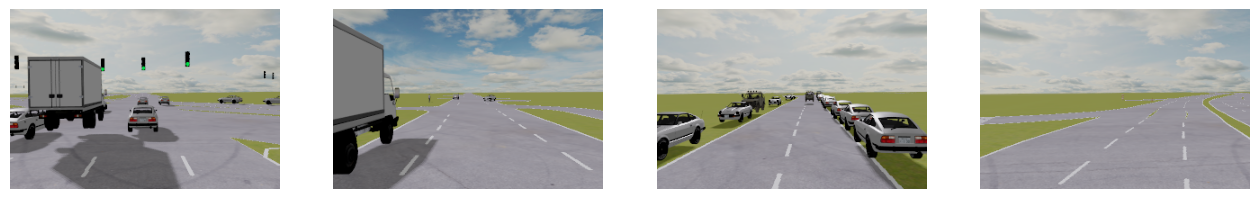

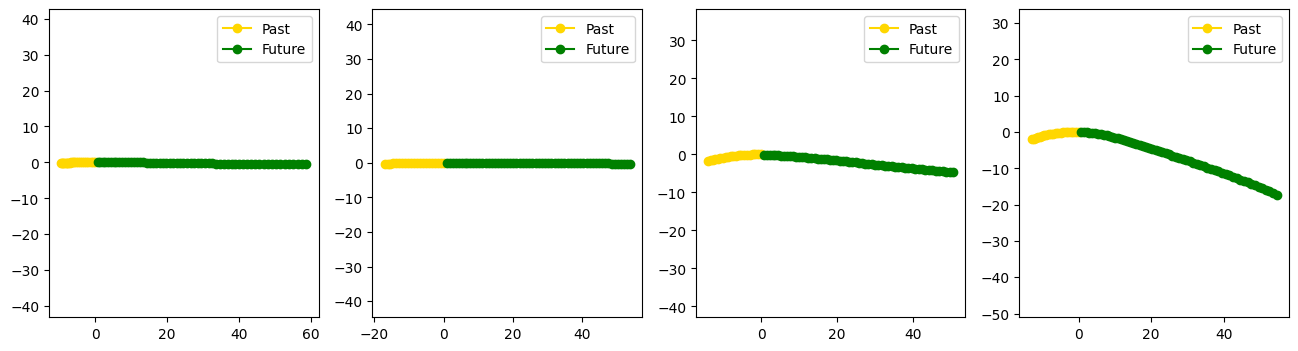

In [3]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import random

k = 4
# load the data
data = []
for i in random.choices(np.arange(1000), k=k):
    with open(f"train/{i}.pkl", "rb") as f:
        data.append(pickle.load(f))

# plot the camera view of current step for the k examples
fig, axis = plt.subplots(1, k, figsize=(4*k, 4))
for i in range(k):
    axis[i].imshow(data[i]["camera"])
    axis[i].axis("off")
plt.show()

# plot the past and future trajectory of the vehicle
fig, axis = plt.subplots(1, k, figsize=(4*k, 4))
for i in range(k):
    axis[i].plot(data[i]["sdc_history_feature"][:, 0], data[i]["sdc_history_feature"][:, 1], "o-", color="gold", label="Past")
    axis[i].plot(data[i]["sdc_future_feature"][:, 0], data[i]["sdc_future_feature"][:, 1], "o-", color="green", label="Future")
    axis[i].legend()
    axis[i].axis("equal")
plt.show()

## Set-Up

Now its time to make our hands dirty!

In the following cells we will define the classes we need to do a proper training in pytorch.

1. We will start with defining a Dataset class which loads the data and does some basic preprocessing. You can further process this data as you see fit.
2. We then define the logger which receives training metrics and logs and prints/visualizes them. Having a good logger means a lot when dealing with neural network training! The logger implemented here is very simple and we strongly suggest you try other ways of visualizing your losses and metrics. Be creative ;)
3. We then proceed with defining the core part of the pipeline, the model. You are going to mainly implement the model yourself, but we have provided a very simple model so that the code runs as is so that you can see how the whole framework runs all in all.
4. Finally, we define the training funciton which contains the training loop, and we call it to see the magic! You'll need to also do a lot of changes here, from the batch size and learning rate, to adding augmentation schemes and schedulers, etc.

### Driving Dataset

In [4]:
import torch
from torch.utils.data import Dataset
import pickle

class DrivingDataset(Dataset):
    def __init__(self, file_list, test=False):
        self.samples = file_list
        self.test = test

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        # Load pickle file
        with open(self.samples[idx], 'rb') as f:
            data = pickle.load(f)

        # Convert numpy arrays to tensors
        camera = torch.FloatTensor(data['camera']).permute(2, 0, 1)
        history = torch.FloatTensor(data['sdc_history_feature'])

        if not self.test:
          future = torch.FloatTensor(data['sdc_future_feature'])
          return {
            'camera': camera,
            'history': history,
            'future': future
          }
        else:
          return {
            'camera': camera,
            'history': history
          }

### Logger

In [5]:
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

class Logger:
    def __init__(self):
        # Placeholder for potential future configs (e.g., log_dir, wandb_enabled, etc.)
        self.loss_val = []
        self.loss_tr  = []
        self.ade_val  = []
        self.fde_val  = []
        self.epoch    = []
        self.best_ade = 50

    def log(self, step=None, **metrics):
        """
        Logs the given metrics.

        Args:
            step (int, optional): The current step or epoch. Useful for tracking.
            **metrics: Arbitrary keyword arguments representing metric names and values.
        """
        for key, val in metrics.items():
            if key == 'loss_val':
                self.loss_val.append(val)
            elif key == 'loss_tr':
                self.loss_tr.append(val)
            elif key == 'ADE':
                self.ade_val.append(val)
                if val < self.best_ade:
                  self.best_ade = val
            elif key == 'FDE':
                self.fde_val.append(val)
            elif key == "epoch":
                self.epoch.append(val)

    def plot(self):
      # Create the subplots
      fig, axs = plt.subplots(1, 5, figsize=(25, 5))  # 1 row, 3 columns

      # 1st subplot: Plot 'a'
      axs[0].plot(self.epoch, self.loss_tr, marker='o', color='blue')
      axs[0].set_title("Training loss")
      axs[0].set_xlabel("Epoch")
      axs[0].set_ylabel("Loss [-]")
      axs[0].grid(True)

      # 2nd subplot: Plot 'b'
      axs[1].plot(self.epoch, self.loss_val, marker='x', color='red')
      axs[1].set_title("Validation Loss")
      axs[1].set_xlabel("Epoch")
      axs[1].set_ylabel("Loss [-]")
      axs[1].grid(True)

      # 3rd subplot: Plot 'c' and 'd'
      axs[2].plot(self.epoch, self.ade_val, marker='x', color='red')
      axs[2].set_title("Validation ADE")
      axs[2].set_xlabel("Epoch")
      axs[2].set_ylabel("Error [-]")
      axs[2].grid(True)

      # 4th subplot
      axs[3].plot(self.epoch, self.fde_val, marker='o', color='blue')
      axs[3].set_title("Validation FDE")
      axs[3].set_xlabel("Epoch")
      axs[3].set_ylabel("Error [-]")
      axs[3].grid(True)

      # 4th subplot
      axs[4].plot(self.epoch, np.array(self.loss_val) - np.array(self.loss_tr), marker='o', color='blue')
      axs[4].set_title("Loss Difference")
      axs[4].set_xlabel("Epoch")
      axs[4].set_ylabel("Val-Train loss [-]")
      axs[4].grid(True)

      fig.tight_layout()
      # Clear the previous plot only
      clear_output(wait=True)
      display(fig)  # Display the current figure

      # Close the figure to avoid duplication in Jupyter
      plt.close(fig)
    def clean(self):
      self.loss_val.pop(0)
      self.loss_tr.pop(0)
      self.ade_val.pop(0)
      self.fde_val.pop(0)
      self.epoch.pop(0)

### Custom Criterion

In [6]:
import sys
from torch import nn
class customCriterion(nn.Module):
  def __init__(self, x_scale = 1.0, y_scale = 1.0, heading_scale = 4.0):
    super(customCriterion, self).__init__()
    self.x_scale = x_scale
    self.y_scale = y_scale
    self.heading_scale = heading_scale

  def forward(self, predictions, target):
    x_error = predictions[:, :, 0] - target[:, :, 0]
    y_error = predictions[:, :, 1] - target[:, :, 1]
    heading_error = predictions[:, :, 2] - target[:, :, 2]
    loss = (self.x_scale * x_error**2 +
              self.y_scale * y_error**2 +
              self.heading_scale * heading_error**2).mean()
    return loss

### Training Function

In [7]:
def train(model, train_loader, val_loader, optimizer, logger, num_epochs=50, start_epoch=0):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    criterion = customCriterion()

    best_ade = 50
    best_dict = {}
    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss = 0
        for idx, batch in enumerate(train_loader):
            camera = batch['camera'].to(device)
            history = batch['history'].to(device)
            future = batch['future'].to(device)

            optimizer.zero_grad()
            pred_future = model(camera, history)
            loss = criterion(pred_future, future)
            loss.backward()
            optimizer.step()

            if idx % 10 == 0:
                logger.log(step=epoch * len(train_loader) + idx, loss=loss.item())
            train_loss += loss.item()

        # Validation
        model.eval()
        val_loss, ade_all, fde_all = 0, [], []
        with torch.no_grad():
            for batch in val_loader:
                camera = batch['camera'].to(device)
                history = batch['history'].to(device)
                future = batch['future'].to(device)

                pred_future = model(camera, history)
                loss = criterion(pred_future, future)
                ADE = torch.norm(pred_future[:, :, :2] - future[:, :, :2], p=2, dim=-1).mean()
                FDE = torch.norm(pred_future[:, -1, :2] - future[:, -1, :2], p=2, dim=-1).mean()
                ade_all.append(ADE.item())
                fde_all.append(FDE.item())
                val_loss += loss.item()

            if np.mean(ade_all) < best_ade:
                best_ade = np.mean(ade_all)
                best_dict = model.state_dict()

        logger.log(loss_tr=train_loss/len(train_loader), loss_val=val_loss/len(val_loader), ADE=np.mean(ade_all), FDE=np.mean(fde_all), epoch=epoch+start_epoch+1)
        logger.plot()
        if( (epoch==0) and (start_epoch==0)):
            logger.clean()

        message = f'Epoch {epoch+1+start_epoch}/{num_epochs+start_epoch} | Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss/len(val_loader):.4f} | ADE: {np.mean(ade_all):.4f} | FDE: {np.mean(fde_all):.4f} | Best ADE: {best_ade:.4f}'
        # print(message)
        sys.stdout.write(f'\n {message}')
        sys.stdout.flush()
    torch.save(model.state_dict(), "phase1_model.pth")

### Neural-Network Architecture

In [8]:
import torch
import torch.nn as nn

class DrivingPlanner(nn.Module):
    def __init__(self): # Changed _init_ to __init__
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=5, stride=2, padding=2),    # C x (100x150)
            nn.ReLU(),
            nn.Conv2d(16, 128, kernel_size=5, stride=2, padding=2),  # C x (50x75)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0),        # C x (25x38)
            nn.Conv2d(128, 256, kernel_size=5, stride=2, padding=2), # C x (13x19)
            nn.ReLU(),
            nn.Conv2d(256, 512, kernel_size=5, stride=2, padding=2), # C x (7x10)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0),        # C x (4x5)
            nn.Flatten(),
            nn.Linear(3 * 5 * 512, 1024),
            nn.ReLU(),
            nn.Linear(1024, 256),
        )

        self.history = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3*21, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
        )

        # Decoder for predicting future trajectory
        self.decoder = nn.Sequential(
            nn.ReLU(),
            nn.Linear(256 + 128, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 60 * 3),
        )

    def forward(self, camera, history):
        # Process camera images
        visual_features = self.cnn(camera)

        # Combine features
        history_latent = self.history(history)

        combined = torch.cat([visual_features, history_latent], dim=1)

        # Predict future trajectory
        future = self.decoder(combined)

        future = future.reshape(-1, 60, 3)  # Reshape to (batch_size, timesteps, features)

        return future

### Load Data-Sets
Here we load the training and validation dataset

In [9]:
import os
from torch.utils.data import DataLoader

# Load Data
train_data_dir = "train"
val_data_dir = "val"

train_files = [os.path.join(train_data_dir, f) for f in os.listdir(train_data_dir) if f.endswith('.pkl')]
val_files = [os.path.join(val_data_dir, f) for f in os.listdir(val_data_dir) if f.endswith('.pkl')]

train_dataset = DrivingDataset(train_files)
val_dataset = DrivingDataset(val_files)

train_loader = DataLoader(train_dataset, batch_size=32, num_workers=2, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, num_workers=2)

## Train
Here we can train the model and view its progress. The logger will plot `['Training Loss', 'Validation Loss', 'Validation ADE', 'Validation FDE', 'Loss difference between validation and training criterion']`.
There will also be a print statement: for example `Epoch 10/N | Train Loss: 0.3368 | Val Loss: 13.8287 | ADE: 1.8458 | FDE: 5.1108 | Best ADE: 1.8324`

To train the model set `train = True`

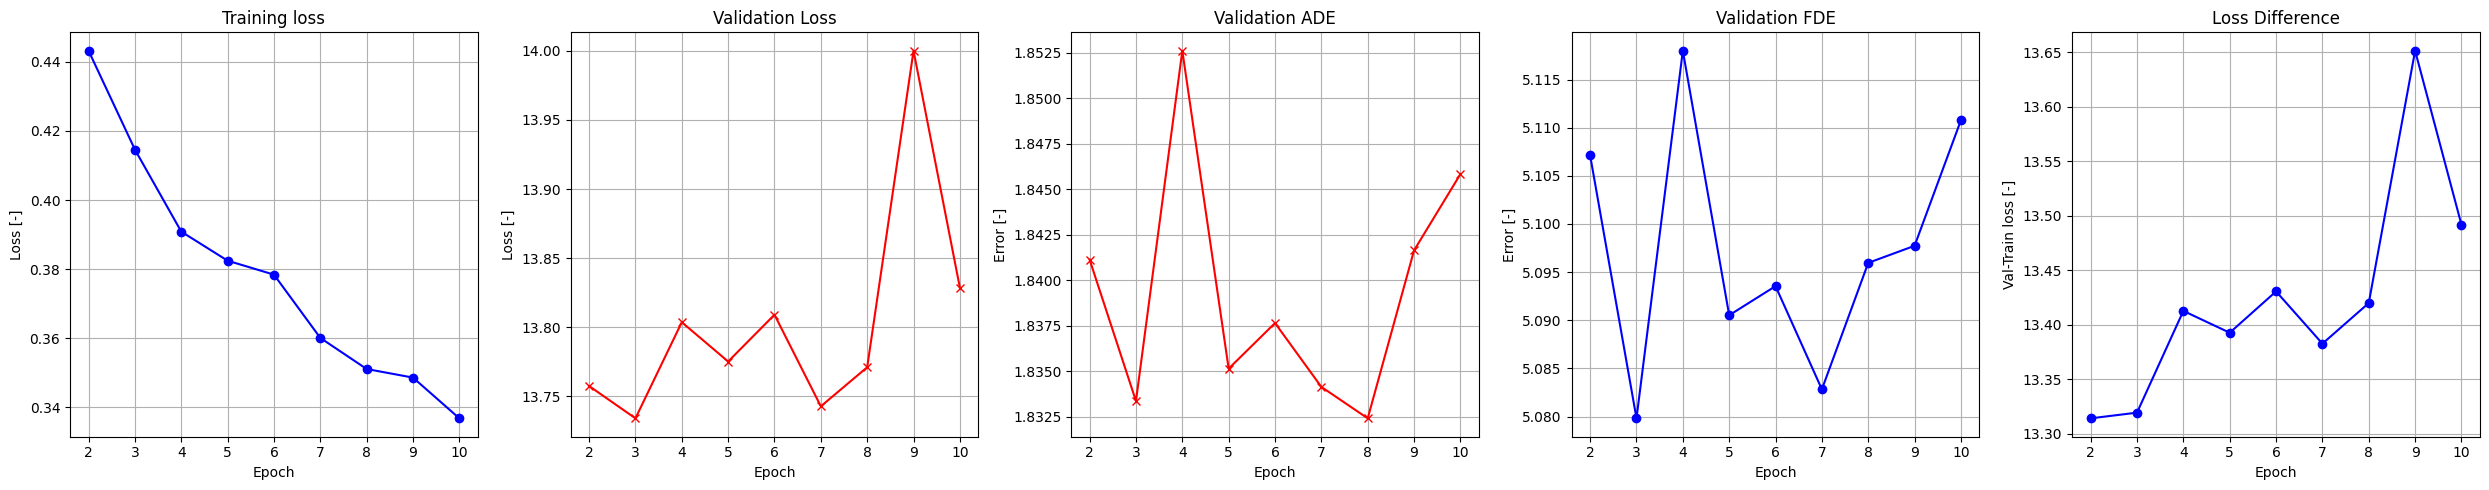


 Epoch 10/10 | Train Loss: 0.3368 | Val Loss: 13.8287 | ADE: 1.8458 | FDE: 5.1108 | Best ADE: 1.8324

In [ ]:
import torch.optim as optim
import time
import gc

train = False

# Clear GPU memory
if 'model' in globals():
    del globals()['model']
gc.collect()
torch.cuda.empty_cache()
time.sleep(4)

if(('model' not in globals()) and train):
  model = DrivingPlanner()

  logger = Logger()
  epochs = [70, 70]

  optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
  train(model, train_loader, val_loader, optimizer, logger, num_epochs=epochs[0])

  optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
  train(model, train_loader, val_loader, optimizer, logger, num_epochs=epochs[1], start_epoch=epochs[0])


By running the code above, you have trained your first model!
What do you observe in terms of train and val losses? What is this phenomenon called? (Explain in a few lines below)

Here are the results from training the first model:<br>
```Epoch 50/50 | Train Loss: 9.8948 | Val Loss: 26.0309 | ADE: 6.6646 | FDE: 12.2324```


Here we notice that the train and val loss decrease at different rates and at some point the train loss is a magnitude lower than validation. This is the case when the model overfits to the training dataset and cannot generalize well with the validation dataset. We also notice that the ADE and loss is still high, which shows that the model is not complex enough to learn the relationships of the data.


This model is very simple and does not necessarilly yield the optimal performance. You are asked to implement your own neural network architecture. You can use convolution networks, vision transformers, etc. Try with different architectures, different model sizes, and other hyper parameters such as learning rate and batch size to find the best performance. Other ideas could be to use augmentation thechniques to boost the performance, adding learning rate schedulers, and exploring other loss functions.

Once you are happy with your model, continue with the rest of the notebook to save your checkpoint and also visualize some plans coming from the model. The last cell will provide a `submission_phase1.csv` which you can submit to the leaderboard to see your results on the testing set.

### Load/Save
Set `load_model = True` to load existing weights on to an architecture. Otherwise `load_model = False` to save the weights of the current model.

In [22]:
load_model = True
path_pth = path_colab + "Weights_V1.pth"

# save the model
if not load_model:
    torch.save(model.state_dict(), "phase1_model.pth")
else:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = DrivingPlanner().to(device)
    model.load_state_dict(torch.load(path_pth))

# Validation
model.eval()
ade_all, fde_all = [], []
with torch.no_grad():
    for batch in val_loader:
        camera = batch['camera'].to(device)
        history = batch['history'].to(device)
        future = batch['future'].to(device)

        pred_future = model(camera, history)
        ADE = torch.norm(pred_future[:, :, :2] - future[:, :, :2], p=2, dim=-1).mean()
        FDE = torch.norm(pred_future[:, -1, :2] - future[:, -1, :2], p=2, dim=-1).mean()
        ade_all.append(ADE.item())
        fde_all.append(FDE.item())

print(f"ADE on validation: {np.mean(ade_all):.4f}")

ADE on validation: 1.8375


## Validation

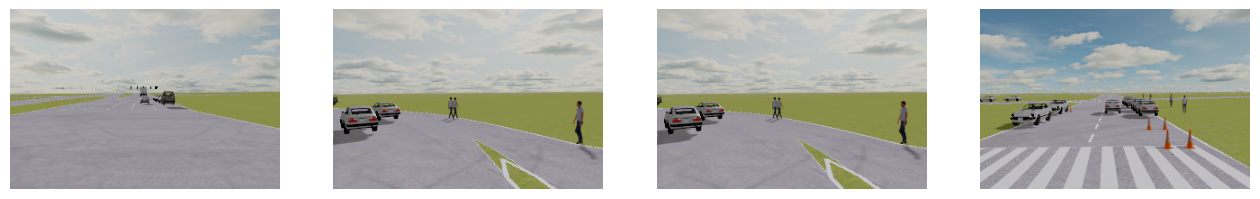

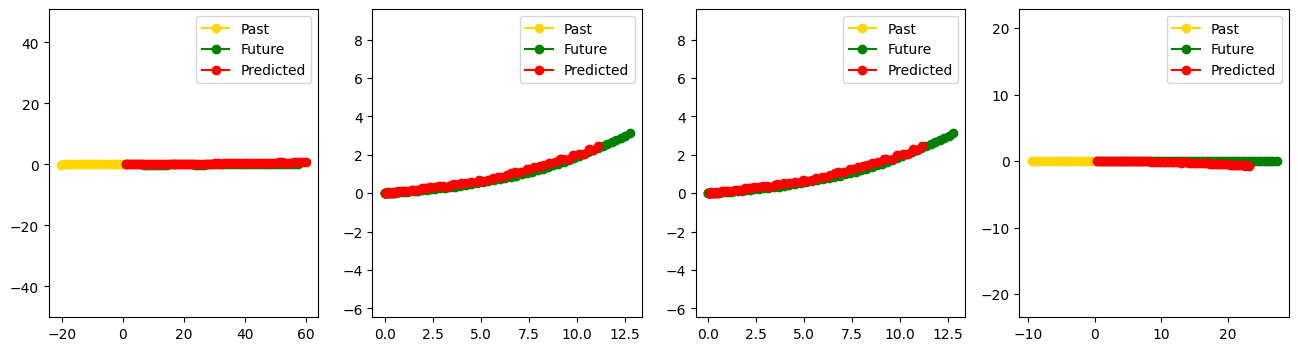

In [21]:
val_batch_zero = next(iter(val_loader))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
camera = val_batch_zero['camera'].to(device)
history = val_batch_zero['history'].to(device)
future = val_batch_zero['future'].to(device)

model.eval()
with torch.no_grad():
    pred_future = model(camera, history)

camera = camera.cpu().numpy()
history = history.cpu().numpy()
future = future.cpu().numpy()
pred_future = pred_future.cpu().numpy()
k=4
selected_indices = random.choices(np.arange(len(camera)), k=k)
# plot the camera view of current step for the k examples
fig, axis = plt.subplots(1, k, figsize=(4*k, 4))
for i, idx in enumerate(selected_indices):
    axis[i].imshow(camera[idx].transpose(1, 2, 0)/255)
    axis[i].axis("off")
plt.show()

# plot the past and future trajectory of the vehicle
fig, axis = plt.subplots(1, k, figsize=(4*k, 4))
for i, idx in enumerate(selected_indices):
    axis[i].plot(history[idx, :, 0], history[idx, :, 1], "o-", color="gold", label="Past")
    axis[i].plot(future[idx, :, 0], future[idx, :, 1], "o-", color="green", label="Future")
    axis[i].plot(pred_future[idx, :, 0], pred_future[idx, :, 1], "o-", color="red", label="Predicted")
    axis[i].legend()
    axis[i].axis("equal")
plt.show()

Now we run our model on the test set once, to get the plan of our model and save it for submission. Notice that the ground truth plans are removed for the test set, so you can not calculate the ADE metric on the test set yourself, and need to submit it to the leader board. By running the last cell, you'll be able to see a csv file called `submission_phase1.csv` by clicking on the folder icon on the left. Download it and submit it to the leaderboard to get your score.

### Generate Submission

In [ ]:
with open(f"test_public/0.pkl", "rb") as f:
    data = pickle.load(f)
print(data.keys())
# Note the absence of sdc_future_feature

dict_keys(['camera', 'depth', 'driving_command', 'sdc_history_feature', 'semantic_label'])


In [ ]:
import pandas as pd
test_data_dir = "test_public"
test_files = [os.path.join(test_data_dir, fn) for fn in sorted([f for f in os.listdir(test_data_dir) if f.endswith(".pkl")], key=lambda fn: int(os.path.splitext(fn)[0]))]

test_dataset = DrivingDataset(test_files, test=True)
test_loader = DataLoader(test_dataset, batch_size=250, num_workers=2)
model.eval()
all_plans = []
with torch.no_grad():
    for batch in test_loader:
        camera = batch['camera'].to(device)
        history = batch['history'].to(device)

        pred_future = model(camera, history)
        all_plans.append(pred_future.cpu().numpy()[..., :2])
all_plans = np.concatenate(all_plans, axis=0)

# Now save the plans as a csv file
pred_xy = all_plans[..., :2]  # shape: (total_samples, T, 2)

# Flatten to (total_samples, T*2)
total_samples, T, D = pred_xy.shape
pred_xy_flat = pred_xy.reshape(total_samples, T * D)

# Build a DataFrame with an ID column
ids = np.arange(total_samples)
df_xy = pd.DataFrame(pred_xy_flat)
df_xy.insert(0, "id", ids)

# Column names: id, x_1, y_1, x_2, y_2, ..., x_T, y_T
new_col_names = ["id"]
for t in range(1, T + 1):
    new_col_names.append(f"x_{t}")
    new_col_names.append(f"y_{t}")
df_xy.columns = new_col_names

# Save to CSV
df_xy.to_csv("submission_phase1.csv", index=False)

print(f"Shape of df_xy: {df_xy.shape}")

Shape of df_xy: (1000, 121)
